# Plotting recommendations for Chem 4410 - Part 1

I have presented some examples of data plots with linear and non-linear regression data analysis in previous classes and will present many more as we proceed. Over the years my methodology has evolved as I learn more about the tools available. You will see many approaches used to reach the exact same conclusions. This document supports a series of *Python* notebooks that present my current methods. Feel free to steal all this work and use it for yourself. All I ask is that you give credit when appropriate.

## Simple Plots

Imagine perfroming a simple kinetics plot of a first-order reaction such as $A\longrightarrow B$. The code below will create random data for such a plot. this data will be used in the subsequent plots and data analysis. Fool around with the numbers and have fun.

### Fake the Data

The code will create a data set of absorbance vs time and save that data to a file. Once we have the data, we can just keep using it over and over again. 

In [16]:
# Generate randome Data for first-oredr chemical kinetics

import numpy as np              # numpy 
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# True reaction parameters
# -------------------------
A0 = 0.80      # Initial absorbance at 254nm
k = 0.150       # First-order rate constant (min^-1)

# -------------------------
# Generate time points
# -------------------------
time = np.linspace(1, 40, 40)  # 15 measurements from 0 to 20 min

# -------------------------
# Calculate true values
# -------------------------
A_true = A0 * np.exp(-k * time)

# -------------------------
# Add experimental error
# -------------------------
np.random.seed(12345)          # For reproducibility - will always get the same series of "random" from a given seed

sigma = 0.03                   # Standard deviation of measurement error (Abs)

A_obs = A_true + np.random.normal(
    loc=0,
    scale=sigma,
    size=len(time)
)

# -------------------------
# Print data table
# -------------------------
print(" Time (min)   Abs A observed (254nm)")
for t, a in zip(time, A_obs):
    print(f"{t:10.2f}   {a:12.4f}")

# -------------------------
# Create DataFrame
# -------------------------
df = pd.DataFrame({
    "Time_min": time,
    "Absorbance_obs": A_obs
})

# -------------------------
# Write to CSV
# -------------------------
filename = "first_order_kinetics.csv"
df.to_csv(filename, 
          index=False,
          float_format="%.3f")

print(f"\n Data written to {filename}")



 Time (min)   Abs A observed (254nm)
      1.00         0.6824
      2.00         0.6070
      3.00         0.4945
      4.00         0.4224
      5.00         0.4369
      6.00         0.3671
      7.00         0.2827
      8.00         0.2494
      9.00         0.2305
     10.00         0.2159
     11.00         0.1839
     12.00         0.0934
     13.00         0.1221
     14.00         0.1048
     15.00         0.1249
     16.00         0.0992
     17.00         0.0024
     18.00         0.0426
     19.00         0.0963
     20.00         0.0267
     21.00         0.0181
     22.00         0.0438
     23.00         0.1229
     24.00        -0.0088
     25.00         0.0015
     26.00         0.0199
     27.00         0.0230
     28.00         0.0277
     29.00         0.0104
     30.00         0.0492
     31.00        -0.0138
     32.00        -0.0184
     33.00        -0.0654
     34.00        -0.0509
     35.00        -0.0216
     36.00         0.0204
     37.00        -0.0349
 

### Load the Data

The code below will import the text from the csv file and create a new dataframe containing the data. We can start here so we use the same data again and again. We can reuse the code above if you want new data. perhaps you want to change the standard deviation of the random error.

In [ ]:
df = pd.read_csv(filename)   # read in the file and convert it to a DataFrame using pandas read_csv tool
print(df.head())             # print just the first few lines

   Time_min  Absorbance_obs
0       1.0           0.682
1       2.0           0.607
2       3.0           0.495
3       4.0           0.422
4       5.0           0.437


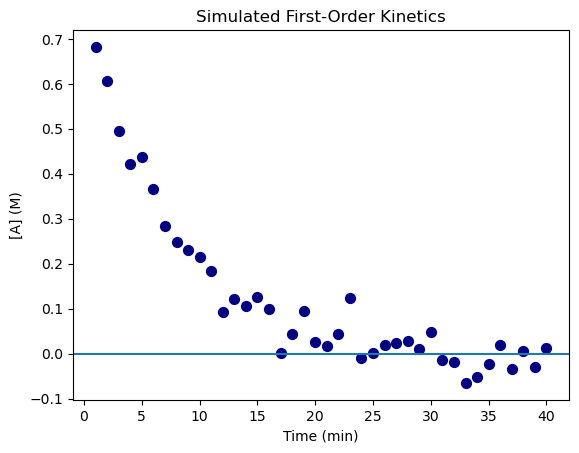

In [24]:
x = df["Time_min"]
y = df["Absorbance_obs"]

# -------------------------
# Plot
# -------------------------
plotname = "plot1.pdf"                        # name of file for plot output. Adding ".pdf" will create pdf filk.

plt.scatter(x, y, color="navy", s=50,
            label="Experimental data")


plt.xlabel("Time (min)")                      # label the axes
plt.ylabel("[A] (M)")
plt.title("Simulated First-Order Kinetics")   # add a title to the plot
#plt.legend()                                 # display a legend on plot
plt.axhline(0)
plt.savefig(plotname)
plt.show()                                    # show the plot